In [1]:
!which python
%load_ext autoreload
%autoreload 2


/home/aaronfurtado/Coding/BE PROJECT/Final/PANI-Precipitaiton-Analysis-for-Natural-Integration/env/bin/python


In [2]:
#If there are issues with importing modules. This is for reloading a module
import importlib
import computations_funcs
import plot_funcs
import data_collection
modules=[computations_funcs,plot_funcs,data_collection]
for module in modules:
    importlib.reload(module)

In [3]:
import ee
from dotenv import load_dotenv
import os
from data_collection import get_state_districs,get_region_for_districts,generate_mask_for_region,get_data_for_districts,get_data_for_rainfall_pred,read_csv_and_convert_to_img_dictionary
import numpy as np
import matplotlib.pyplot as plt
from computations_funcs import smooth_stack_from_array_dict , resize_img ,generate_probability_mask,convert_smooth_data_to_bins,create_balanced_csv
from data_initialization import categorical_labels,band_cmaps,mcdm_weights
from plot_funcs import plot_bands_one_by_one,visualize_distribution
import matplotlib.colors as mcolors
import rasterio



load_dotenv()

PROJECT_NAME = os.getenv("PROJECT_NAME")
if PROJECT_NAME is None:
    raise Exception("Please set the PROJECT_NAME environment variable")

In [4]:
print('Initializing Earth Engine')
try:
    ee.Initialize(project=PROJECT_NAME)
    print(f'Successfully initialized Earth Engine Project {PROJECT_NAME}')
except Exception as e:
    print('Initializing Earth Engine for the first time')
    ee.Authenticate()
    ee.Initialize(project=PROJECT_NAME)
    print(f'Successfully initialized Earth Engine Project {PROJECT_NAME}')
# NOTE: This is a test to check if ee is initialized
# image = ee.Image('USGS/SRTMGL1_003')
# print(image.getInfo())

Initializing Earth Engine
Successfully initialized Earth Engine Project be-project-aaronfurtado2003


In [5]:
state=''
while(state==''):
    state=input("Please Enter a state name:")

state_source,districts=get_state_districs(state)
print(f'List of Districts in {state} are:\n{','.join(districts)}')
print('\n')
selected_districts_unfiltered=input("Please Enter the name of the Districts separated by comma:\n")
selected_districts=selected_districts_unfiltered.split(',')
selected_districts=[district.strip() for district in selected_districts]

print(f'Selected Districts are:\n{','.join(selected_districts)}')

List of Districts in Maharashtra are:
Nandurbar,Akola,Amravati,Bhandara,Buldana,Chandrapur,Dhule,Garhchiroli,Jalgaon,Kolhapur,Latur,Nagpur,Nanded,Nashik,Osmanabad,Pune,Raigarh,Ratnagiri,Sindhudurg,Sangli,Satara,Solapur,Thane,Wardha,Yavatmal,Aurangabad,Ahmednagar,Bid,Gondiya,Hingoli,Jalna,Mumbai Suburban,Mumbai city,Parbhani,Washim


Selected Districts are:
Aurangabad,Bid,Hingoli,Latur,Osmanabad,Jalna,Parbhani,Nanded


In [6]:
print(f'Getting region scale and boundary for districts')
region,scale,region_self_mask=get_region_for_districts(state_source,selected_districts)

print(f'Generating masks for selected region')
mask_projection,region_mask=generate_mask_for_region(region,scale)
print(f'Collecting data for {','.join(selected_districts)}')

Getting region scale and boundary for districts
Generating masks for selected region


/home/aaronfurtado/Coding/BE PROJECT/Final/PANI-Precipitaiton-Analysis-for-Natural-Integration/env/lib/python3.13/site-packages/ee/deprecation.py:207: DeprecationWarning: 

Attention required for COPERNICUS/S2_SR! You are using a deprecated asset.
To make sure your code keeps working, please update it.
Learn more: https://developers.google.com/earth-engine/datasets/catalog/COPERNICUS_S2_SR

  warnings.warn(warning, category=DeprecationWarning)


In [ ]:
#RUN ONLY FOR DATA COLLECTION
exported_file_name='era5_2000_point_data_marathwada'
mask_value=999999
rain_dict=get_data_for_rainfall_pred(
    region,
    scale,
    mask_projection,
    region_self_mask,
    exported_file_name,
    mask_value,
    sample_points=2000
    )

In [7]:
#RUN FOR PROCESSING CSV DATA AND GETTING IMAGES
era5_csv_path='era5_2000_point_data_marathwada.csv'
smoothing_coeff=3
joblib_path='era5_2000_point_data_marathwada'
save_dir='era5_2000_point_data_marathwada_out_geotifs/'
year='2024'
data_output=read_csv_and_convert_to_img_dictionary(
    era5_csv_path,
    region,
    mask_projection,
    region_self_mask,
    scale,
    image_res=512,
    smoothing_coeff=smoothing_coeff,
    save_data=True,
    joblib_path=joblib_path,
    save_dir=save_dir,
    year=year,
    save=True
    )

Region Bounds: [74.59639963233387, 17.641871447668745, 78.36773784369562, 20.672191810432107]
Image Shape: (411, 512)
100 entries completed
200 entries completed
300 entries completed
✅ Saved all GeoTIFFs to: era5_2000_point_data_marathwada_out_geotifs/2024
✅ Saved data dictionary as joblib: era5_2000_point_data_marathwada_2024.joblib


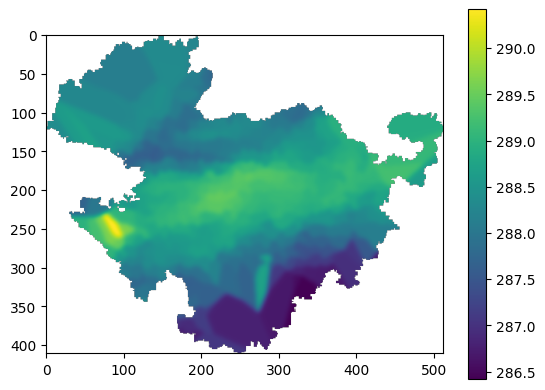

In [37]:
plt.imshow(data_output['dewpoint_temperature_2m']['2021-01-01'])
plt.colorbar()